In [1]:
import gymnasium as gym  # Usamos gymnasium agora (padrão atual)
import numpy as np
import cv2
import ale_py
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecVideoRecorder
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.atari_wrappers import FireResetEnv, ClipRewardEnv
from gymnasium.wrappers import ResizeObservation

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
gym.register_envs(ale_py)

In [4]:
log_dir = "./logs_breakout/"
os.makedirs(log_dir, exist_ok=True)

In [5]:
class BlurBreakout(gym.Wrapper):
    def __init__(self, env, blur=False, region=(0, 0, 80, 80), ksize=15):
        super().__init__(env)
        self.blur = blur
        self.x, self.y, self.w, self.h = region
        self.ksize = ksize
        # Garante que ksize seja ímpar para o GaussianBlur
        if self.ksize % 2 == 0: self.ksize += 1

    def _apply_blur(self, obs):
        if not self.blur:
            return obs
        
        # O obs aqui chega como (H, W, C)
        # Copia para não alterar buffer interno do Gym
        img = obs.copy()
        
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante limites da imagem
        H, W, _ = img.shape
        y_end = min(y + h, H)
        x_end = min(x + w, W)

        patch = img[y:y_end, x:x_end]
        if patch.size > 0:
            patch_blur = cv2.GaussianBlur(patch, (self.ksize, self.ksize), 0)
            img[y:y_end, x:x_end] = patch_blur
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._apply_blur(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._apply_blur(obs), reward, terminated, truncated, info

In [6]:
class WhitePatchBreakout(gym.Wrapper):
    def __init__(self, env, apply_patch=False, region=(0, 0, 50, 50)):
        super().__init__(env)
        self.apply_patch = apply_patch
        self.x, self.y, self.w, self.h = region

    def _paint_patch(self, img):
        # Função auxiliar para pintar a imagem
        if not self.apply_patch:
            return img
        
        # Copia para não estragar o buffer original
        img = img.copy()
        
        # Pega dimensões
        H, W, C = img.shape
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante que não saia da tela
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        # Aplica a mancha branca (255)
        # Verifica se a região é válida
        if y < y_end and x < x_end:
            img[y:y_end, x:x_end] = 255
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        # Aplica na observação do agente
        return self._paint_patch(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        # Aplica na observação do agente
        return self._paint_patch(obs), reward, terminated, truncated, info

    def render(self):
        # --- A MÁGICA ACONTECE AQUI ---
        # Pegamos a imagem original do emulador
        img = self.env.render()
        
        # E aplicamos a mancha nela também antes de mostrar/gravar
        return self._paint_patch(img)

In [ ]:
class GrayscaleWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(old_shape[0], old_shape[1], 1), dtype=np.uint8
        )

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._convert(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._convert(obs), reward, terminated, truncated, info

    def _convert(self, obs):
        if obs.ndim == 3 and obs.shape[2] == 3:
            return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)[:, :, None]
        return obs

In [8]:
def create_env(with_blur=False, render_mode=None, change = 'white_patch', log_dir=None):
    # Usamos o ID 'BreakoutNoFrameskip-v4' que é padrão em RL
    env = gym.make("ALE/Breakout-v5", render_mode=render_mode)

    env = FireResetEnv(env)
    # env = ClipRewardEnv(env)
    if change == 'blur':
        env = BlurBreakout(env, blur=with_blur, region=(50, 50, 100, 60), ksize=21)
    elif change == 'white_patch':
        env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
    else:
        env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
    env = ResizeObservation(env, (84, 84))
    env = GrayscaleWrapper(env)
    
    # Aplica o Wrapper de Blur ANTES dos wrappers de pré-processamento do Atari
    
    env = Monitor(env, log_dir) # Para logs
    return env

In [9]:
def make_training_env(with_blur, log_dir, change = 'white_patch'):
    # Cria diretório se não existir
    os.makedirs(log_dir, exist_ok=True)

    # 1. Cria o ambiente (DummyVecEnv)
    env = DummyVecEnv([
        lambda: create_env(with_blur=with_blur, log_dir=log_dir, change=change, render_mode=None)
    ])
    
    # 2. Transpõe as dimensões (HxWxC para CxHxW) para o Pytorch/CNN
    env = VecTransposeImage(env)
    
    # 3. Empilha os Frames (IMPORTANTE para o DQN)
    # Stacka 4 frames (84x84x4)
    env = VecFrameStack(env, n_stack=4)
    return env

In [10]:
log_dir_clean = "./logs_clean/"   # Pasta para o treino NORMAL
log_dir_patch = "./logs_patch/"   # Pasta para o treino COM MANCHA

In [11]:
print("--- Iniciando Treino SEM Blur ---")
env_normal = make_training_env(with_blur=False, change = 'white_patch', log_dir=log_dir_clean)
model_normal = DQN("CnnPolicy", env_normal, verbose=1, buffer_size=10000, learning_starts=10000, train_freq=4)
model_normal.learn(total_timesteps=200_000) # Baixo para teste rápido
model_normal.save("dqn_breakout_normal")
env_normal.close()

--- Iniciando Treino SEM Blur ---
Using cpu device
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 204      |
|    ep_rew_mean      | 2.25     |
|    exploration_rate | 0.961    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1484     |
|    time_elapsed     | 0        |
|    total_timesteps  | 816      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 194      |
|    ep_rew_mean      | 1.88     |
|    exploration_rate | 0.926    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1501     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1552     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 180      |
|    ep_rew_mean      | 1.5      |
|    exploration_rate | 0.897    |
| ti

In [12]:
print("\n--- Iniciando Treino COM Blur ---")
env_blur = make_training_env(with_blur=True, change = 'white_patch', log_dir=log_dir_patch)
model_blur = DQN("CnnPolicy", env_blur, verbose=1, buffer_size=10000, learning_starts=10000, train_freq=4)
model_blur.learn(total_timesteps=200_000) # Baixo para teste rápido
model_blur.save("dqn_breakout_blur")
env_blur.close()


--- Iniciando Treino COM Blur ---
Using cpu device
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 170      |
|    ep_rew_mean      | 1        |
|    exploration_rate | 0.968    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1310     |
|    time_elapsed     | 0        |
|    total_timesteps  | 681      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 171      |
|    ep_rew_mean      | 1.12     |
|    exploration_rate | 0.935    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1351     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1370     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 164      |
|    ep_rew_mean      | 0.917    |
|    exploration_rate | 0.907    |
| t

In [13]:
def plot_comparison(log_dir_1, name_1, log_dir_2, name_2):
    plt.figure(figsize=(12, 6))
    
    # Função auxiliar para ler e tratar os dados
    def read_data(folder):
        file_path = os.path.join(folder, "monitor.csv")
        if not os.path.exists(file_path):
            print(f"Aviso: Arquivo não encontrado em {folder}")
            return None, None
        
        df = pd.read_csv(file_path, skiprows=1)
        x = df['l'].cumsum() # Steps acumulados
        y = df['r']          # Recompensa
        # Suavização (Média móvel de 100 episódios)
        y_smooth = y.rolling(window=100).mean()
        return x, y_smooth

    # Plota o Primeiro (Sem Mancha)
    x1, y1 = read_data(log_dir_1)
    if x1 is not None:
        plt.plot(x1, y1, label=name_1, color='blue', linewidth=2)

    # Plota o Segundo (Com Mancha)
    x2, y2 = read_data(log_dir_2)
    if x2 is not None:
        plt.plot(x2, y2, label=name_2, color='red', linewidth=2, linestyle='--')

    plt.xlabel('Timesteps (Passos)')
    plt.ylabel('Recompensa Média (Média Móvel 100 ep)')
    plt.title('Comparação de Performance: Normal vs Oclusão')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



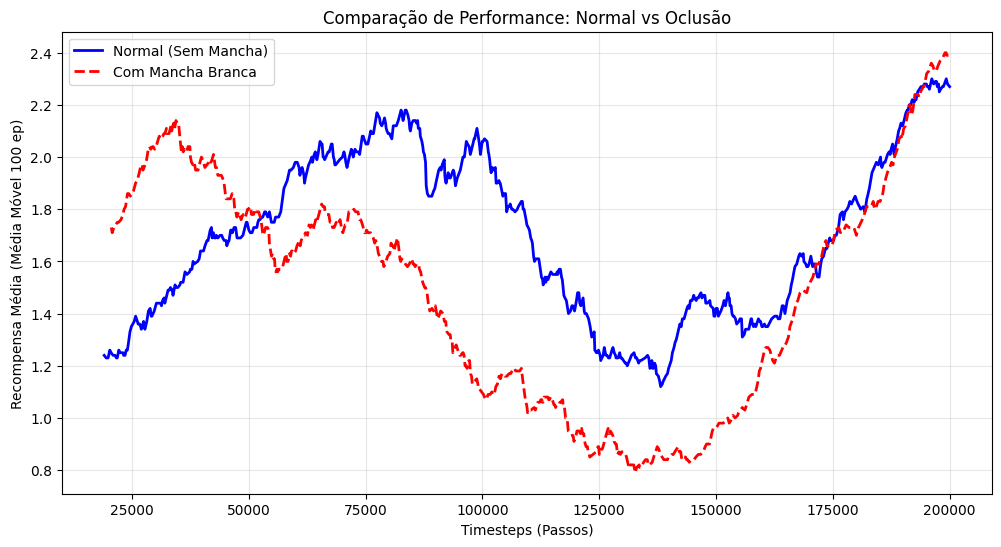

In [14]:
# Chama a função comparando as pastas que criamos antes
plot_comparison("./logs_clean/", "Normal (Sem Mancha)", 
                "./logs_patch/", "Com Mancha Branca")

In [ ]:
def create_eval_env(with_blur=False, video_folder="./videos/", prefix="video", change=None):
    # Render mode RGB é obrigatório para gravação
    env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
    
    # 1.1 FireReset: Garante start inicial.
    env = FireResetEnv(env)
    
    # 1.2 RecordVideo AQUI: Grava a imagem Pura e Colorida antes de qualquer alteração
    # Isso resolve o problema da tela piscando
    env = gym.wrappers.RecordVideo(
        env, 
        video_folder=video_folder, 
        name_prefix=prefix,
        episode_trigger=lambda x: True, # Grava todos os episódios chamados
        disable_logger=True
    )

    # 1.3 Adiciona Blur se necessário
    if with_blur:
        env = BlurWrapper(env, change=change)

    # 1.4 Redimensiona e Converte para Cinza (O que o robô vê)
    env = gym.wrappers.ResizeObservation(env, (84, 84))
    env = GrayscaleWrapper(env) # Seu wrapper corrigido (H, W, 1)
    
    return env

In [15]:
def record_video(model, name_prefix, with_blur, change, n_episodes=1):
    video_folder = "./videos/"
    os.makedirs(video_folder, exist_ok=True)

    # Cria ambiente
    env = DummyVecEnv([lambda: create_env(with_blur=with_blur, render_mode="rgb_array", change=change)])
    
    # Ordem Correta para SB3:
    # 1. Transpose (H,W,C -> C,H,W)
    env = VecTransposeImage(env)
    
    # 2. FrameStack (Empilha 4 frames -> 4,H,W)
    env = VecFrameStack(env, n_stack=4)

    # 3. VideoRecorder (Por último)
    # O VecVideoRecorder tentará usar o render() interno do gym.make
    env = VecVideoRecorder(
        env,
        video_folder,
        record_video_trigger=lambda x: x == 0,
        video_length=100000,
        name_prefix=name_prefix
    )

    obs = env.reset()
    episodes_count = 0
    
    print(f"--- Gravando {n_episodes} Episódios ---")
    try:
        while episodes_count < n_episodes:
            # Importante: deterministic=False às vezes ajuda a destravar se o agente ficar repetindo movimentos
            action, _ = model.predict(obs, deterministic=True) 
            
            obs, _, done, infos = env.step(action)
            
            # Verifica fim de episódio
            for info in infos:
                if "episode" in info:
                    episodes_count += 1
                    print(f"Episódio {episodes_count} | Score: {info['episode']['r']}")
                    
    except KeyboardInterrupt:
        pass
    finally:
        env.close()
        print(f"Vídeo salvo em {video_folder}")

In [16]:
record_video(model_blur, "teste_com_blur", with_blur=True, change = 'white_patch')

--- Gravando 1 Episódios ---
Episódio 1 | Score: 0.0
MoviePy - Building video c:\Users\user\Documents\mestrado\BlurRL\videos\teste_com_blur-step-0-to-step-100000.mp4.
MoviePy - Writing video c:\Users\user\Documents\mestrado\BlurRL\videos\teste_com_blur-step-0-to-step-100000.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\user\Documents\mestrado\BlurRL\videos\teste_com_blur-step-0-to-step-100000.mp4
Vídeo salvo em ./videos/


In [17]:
record_video(model_normal, "teste_sem_blur", with_blur=False, change = 'white_patch', n_episodes=2)

--- Gravando 2 Episódios ---
Episódio 1 | Score: 0.0
Episódio 2 | Score: 2.0
MoviePy - Building video c:\Users\user\Documents\mestrado\BlurRL\videos\teste_sem_blur-step-0-to-step-100000.mp4.
MoviePy - Writing video c:\Users\user\Documents\mestrado\BlurRL\videos\teste_sem_blur-step-0-to-step-100000.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\user\Documents\mestrado\BlurRL\videos\teste_sem_blur-step-0-to-step-100000.mp4
Vídeo salvo em ./videos/
